In [2]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

In [27]:
# import ROOT as r
# import warnings
# warnings.filterwarnings('ignore')

In [28]:
# r.gSystem.Load('$EVNDISPSYS/lib/libVAnaSum.so')

In [29]:
# filename = '/raid/reedbuck/lrizk/veritas/sources/UMa3/evndisp/muons/111645_muons.root'
# evndisp_file = r.TFile(filename)
# params = evndisp_file.Get('Tel_2/tpars')

In [30]:
# num_events = 0
# for event in params:
#     if event.muonValid and event.muonRadius:
#         num_events += 1

In [31]:
# real_muon_params = np.zeros((3, num_events))
# i = 0

# for event in params:
#     if event.muonValid and event.muonRadius:
#         real_muon_params[0][i] = event.muonRadius
#         real_muon_params[1][i] = event.muonRSigma
#         real_muon_params[2][i] = event.muonIPCorrectedSize
#         i += 1

In [32]:
# output = 'real_data/muons_111645.csv'
# np.savetxt(output, real_muon_params.T, delimiter=',')

In [9]:
real_data = 'real_data/muons_111645.csv'
muon_radii, muon_radii_err, muon_sizes = np.loadtxt(real_data, delimiter=',', unpack=True)

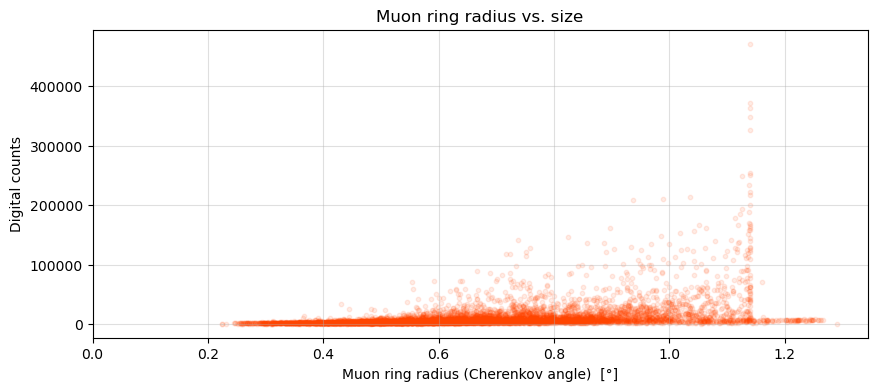

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.scatter(muon_radii, muon_sizes, c='orangered', marker='o', s=10, alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)

plt.show()

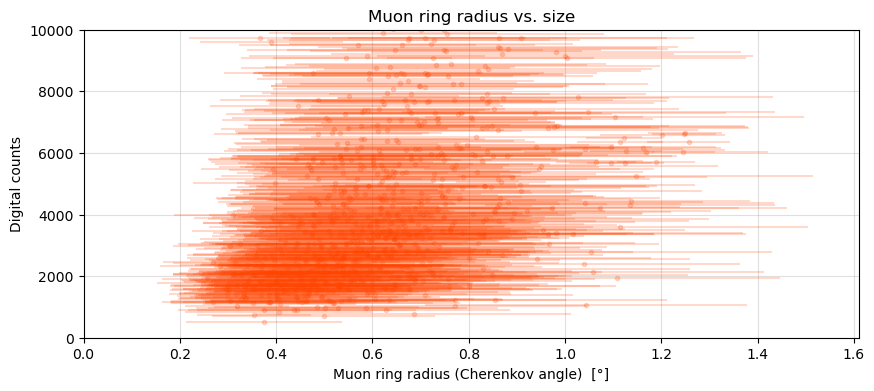

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii[:1000], xerr=muon_radii_err[:1000], y=muon_sizes[:1000],
             c='orangered', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(0, 1e4)

plt.show()

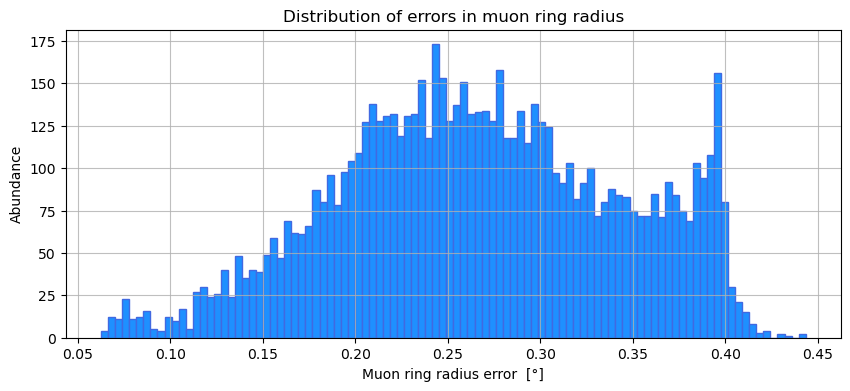

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

hist_data = plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.show()

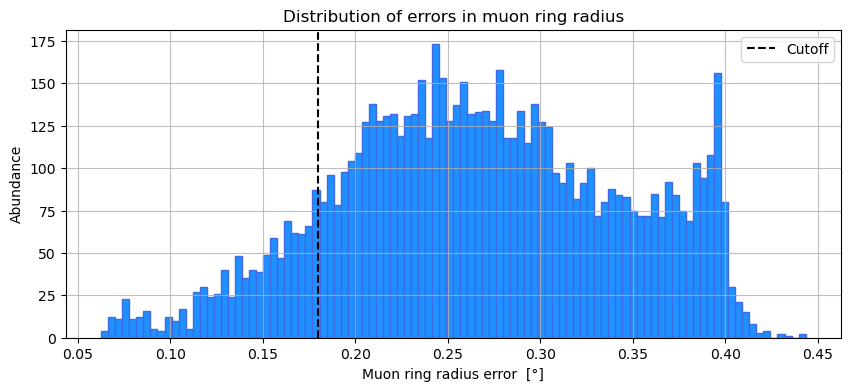

In [24]:
err_cutoff = 0.18

fig, ax = plt.subplots(figsize=(10, 4))

plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')
plt.axvline(x=err_cutoff, c='black', ls='--', label='Cutoff')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.legend()
plt.show()

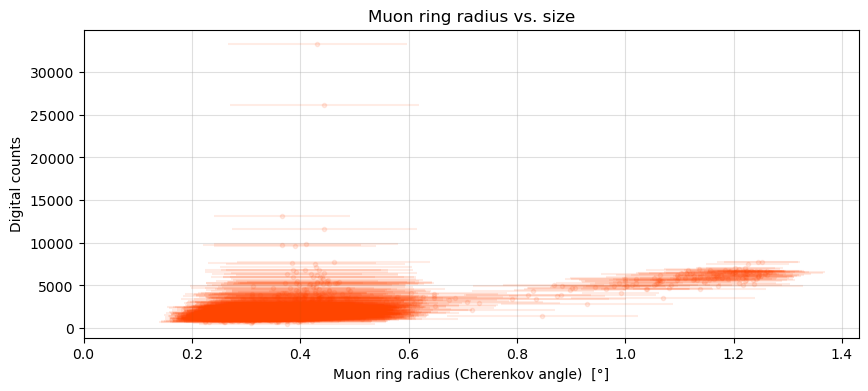

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii[muon_radii_err < err_cutoff], 
             xerr=muon_radii_err[muon_radii_err < err_cutoff],
             y=muon_sizes[muon_radii_err < err_cutoff],
             c='orangered', marker='o', ms=3, ls='', alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)

plt.show()

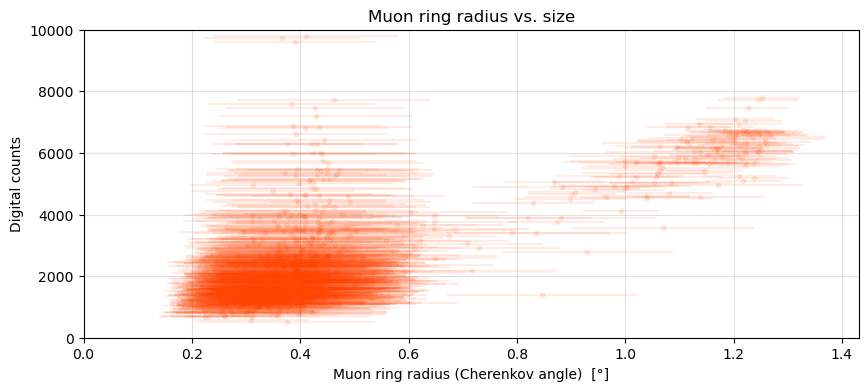

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii[muon_radii_err < err_cutoff], 
             xerr=muon_radii_err[muon_radii_err < err_cutoff],
             y=muon_sizes[muon_radii_err < err_cutoff],
             c='orangered', marker='o', ms=3, ls='', alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(0, 1e4)

plt.show()